### Step1: Import Libraries

In [5]:
import pandas as pd # read and manipulate data
import numpy as np # numerical operations.
import matplotlib.pyplot as plt # create graphs and visualizations.
import seaborn as sns

### Step 2 – Load Dataset

In [6]:
# creates a DataFrame where all rows and columns are stored
data = pd.read_csv("synthetic_black_friday_sales.csv")

### Step 3- Explore the Data

In [7]:
# data.head() [Displays the first five rows of the dataset.]

In [8]:
#data.tail() [Displays the last five rows.]

In [9]:
data.sample() # Shows random rows

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
173,1001291,P2539,F,18-25,12,A,2,1,1,2.0,NaN,649


In [10]:
data.shape # size of dataset.

(5000, 12)

In [11]:
# Calculates statistical information
data.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.000000e+03,5000.000000,5000.000000,5000.000000,3400.000000,1500.000000,5000.000000
mean,1.004966e+06,10.020400,0.419000,10.427800,8.967059,9.531333,6912.376800
std,2.864313e+03,6.028702,0.493445,5.772092,4.846339,5.255165,2616.044798
min,1.000001e+06,0.000000,0.000000,1.000000,1.000000,1.000000,200.000000
25%,1.002492e+06,5.000000,0.000000,5.000000,5.000000,5.000000,4908.750000
50%,1.004974e+06,10.000000,0.000000,10.000000,9.000000,9.000000,6872.000000
75%,1.007381e+06,15.000000,1.000000,15.000000,13.000000,14.000000,8944.500000
max,1.009998e+06,20.000000,1.000000,20.000000,17.000000,18.000000,14320.000000


In [12]:
data.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='str')

In [13]:
# quick overview of the dataset
# identify missing values and understand the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     5000 non-null   int64  
 1   Product_ID                  5000 non-null   str    
 2   Gender                      5000 non-null   str    
 3   Age                         5000 non-null   str    
 4   Occupation                  5000 non-null   int64  
 5   City_Category               5000 non-null   str    
 6   Stay_In_Current_City_Years  5000 non-null   str    
 7   Marital_Status              5000 non-null   int64  
 8   Product_Category_1          5000 non-null   int64  
 9   Product_Category_2          3400 non-null   float64
 10  Product_Category_3          1500 non-null   float64
 11  Purchase                    5000 non-null   int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 468.9 KB


### Step 4: Identify the missing values

In [14]:
# isnull is Panda Function
# Null values reduces the quality of analysis.

data.isnull().sum()

User_ID                          0
Product_ID                       0
Gender                           0
Age                              0
Occupation                       0
City_Category                    0
Stay_In_Current_City_Years       0
Marital_Status                   0
Product_Category_1               0
Product_Category_2            1600
Product_Category_3            3500
Purchase                         0
dtype: int64

### Step-5 Finding percentage of null values in each column 

In [15]:
# percentage hepls to decide whether to drop or fill the missing values.
(data.isnull().sum()/len(data))*100

User_ID                        0.0
Product_ID                     0.0
Gender                         0.0
Age                            0.0
Occupation                     0.0
City_Category                  0.0
Stay_In_Current_City_Years     0.0
Marital_Status                 0.0
Product_Category_1             0.0
Product_Category_2            32.0
Product_Category_3            70.0
Purchase                       0.0
dtype: float64

In [16]:
data = data.drop(columns=["Product_Category_3"])

In [17]:
data.sample()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
2786,1006796,P8420,M,18-25,16,C,1,0,16,NaN,11375


### Step 6 – Separate Numerical & Categorical Columns
#### It require different preprocessing method

In [18]:
num=[] # Create empty lists
cat=[]
for x in data.columns: # returns all column names
    if data[x].dtype=='str':
        cat.append(x) # add column name to cat
    else:
        num.append(x)
print("cat",cat)
print("num",num)

cat ['Product_ID', 'Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']
num ['User_ID', 'Occupation', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Purchase']


### Finding the Outliers

In [19]:
for col in num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

User_ID: 0 outliers
Occupation: 0 outliers
Marital_Status: 0 outliers
Product_Category_1: 0 outliers
Product_Category_2: 0 outliers
Purchase: 0 outliers


In [20]:
data.isnull().sum()

User_ID                          0
Product_ID                       0
Gender                           0
Age                              0
Occupation                       0
City_Category                    0
Stay_In_Current_City_Years       0
Marital_Status                   0
Product_Category_1               0
Product_Category_2            1600
Purchase                         0
dtype: int64

In [21]:
data["Product_Category_2"]=data["Product_Category_2"].fillna(data["Product_Category_2"].mean())

In [22]:
# print(data["Product_Category_2"].mean())

In [23]:
#data["Product_Category_2"].fillna(8)

In [24]:
data[cat].isnull().sum()

Product_ID                    0
Gender                        0
Age                           0
City_Category                 0
Stay_In_Current_City_Years    0
dtype: int64

In [25]:
data.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Purchase                      0
dtype: int64

In [26]:
data["Product_Category_2"] = data["Product_Category_2"].fillna(8)

In [27]:
data.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Purchase                      0
dtype: int64

In [28]:
data.drop_duplicates(inplace=True)

### PLOTS

In [29]:
num

['User_ID',
 'Occupation',
 'Marital_Status',
 'Product_Category_1',
 'Product_Category_2',
 'Purchase']

In [30]:
cat

['Product_ID', 'Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']

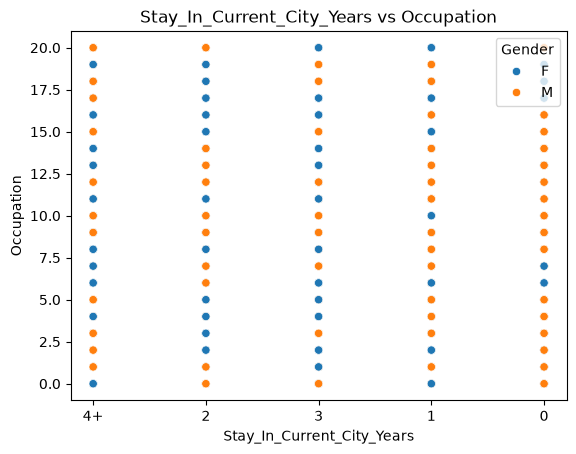

In [31]:
# 1. scatter plot 
sns.scatterplot(data=data,x="Stay_In_Current_City_Years",y="Occupation",hue="Gender")
plt.title("Stay_In_Current_City_Years vs Occupation")
plt.show()


### LINE PLOT

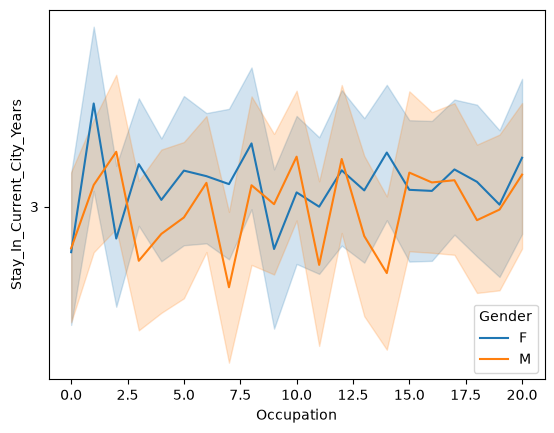

In [32]:
sns.lineplot(data=data,x='Occupation',y='Stay_In_Current_City_Years',hue="Gender")
plt.show()

## Bar Plot

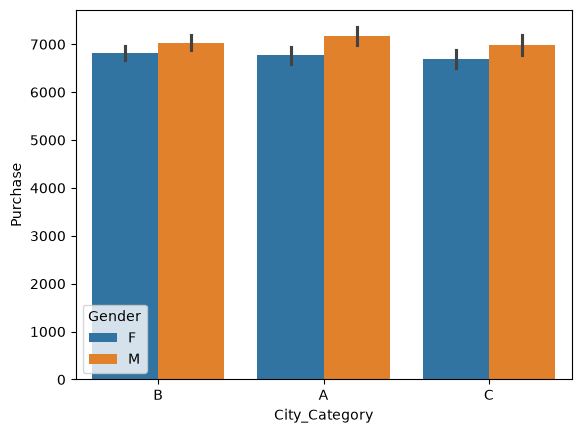

In [33]:

sns.barplot(data=data, x="City_Category", y="Purchase", hue="Gender")
plt.show()

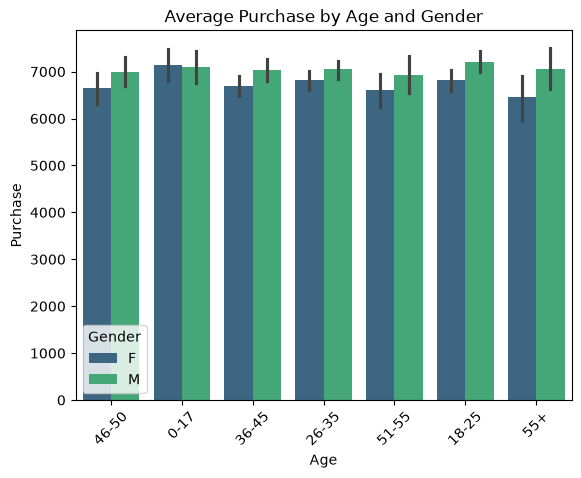

In [34]:
sns.barplot(
    data=data,x="Age",y="Purchase",hue="Gender",palette="viridis")

plt.title("Average Purchase by Age and Gender")
plt.xticks(rotation=45)
plt.show()

## ScatterPLot

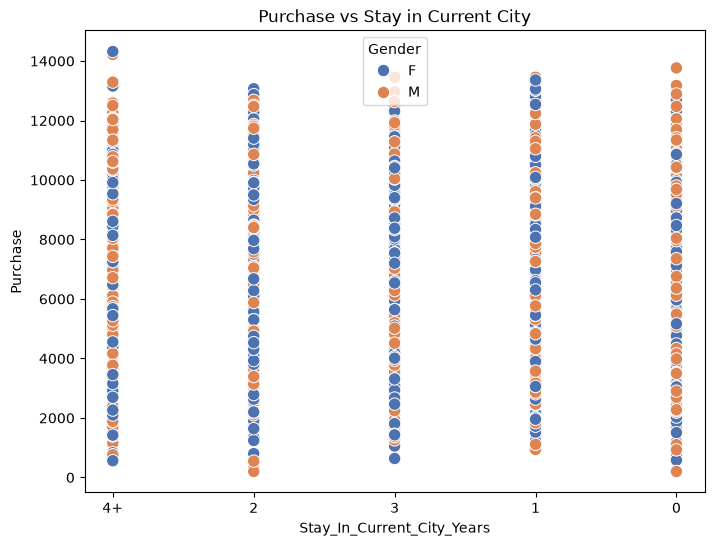

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="Stay_In_Current_City_Years",
    y="Purchase",
    hue="Gender",
    palette="deep",
    s=80
)

plt.title("Purchase vs Stay in Current City")
plt.show()

Pie-Chart

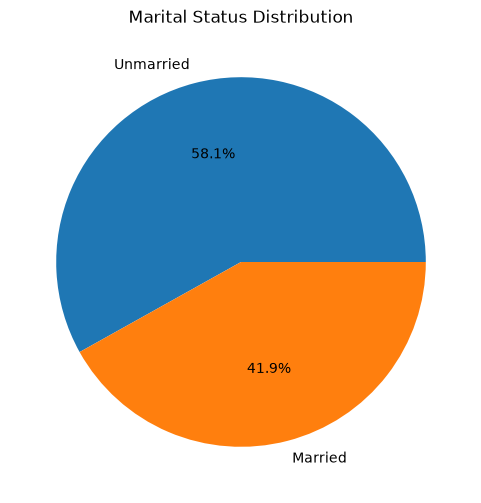

In [36]:
plt.figure(figsize=(6,6))

plt.pie(
    data["Marital_Status"].value_counts(),
    labels=["Unmarried","Married"],
    autopct="%1.1f%%"
)

plt.title("Marital Status Distribution")
plt.show()

MACHINE LEARNING(ML)

In [37]:
# IMPORTING Libraries /for ML Prediction

from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()

In [38]:
# encoding categorical columns into Numerical Values
for i in data.columns:
    if data[i].dtype=="str":
        data[i]=LE.fit_transform(data[i])
    else:
        pass

In [39]:
data.sample()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
2278,1008789,2257,0,3,13,0,3,0,9,8.967059,5720


In [40]:
data.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Purchase'],
      dtype='str')

In [41]:
# input features selection
x=data.iloc[:,1: -2]
y=data["Purchase"]

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [43]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [44]:
LR.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ -0.01,303.81,-19.43,..., -2.12,-23.69,398.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Product_ID','Gender','Age',...,'Stay_In_Current_City_Years', 'Marital_Status','Product_Category_1']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2043
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [45]:
predict=LR.predict(x_test)

### Model Accuracy Evaluation

In [46]:
LR.score(x_test,y_test)

0.809992208807822

In [47]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE :",mean_absolute_error(y_test, predict))
print("MSE:", mean_squared_error(y_test, predict) )


MAE : 907.7223880278564
MSE: 1316485.5168776517


#### LOGISTIC REGRESSION MODEL FOR PREDICTION

In [48]:
data.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Purchase'],
      dtype='str')

### Input features Selection

In [49]:
log_x=data.loc[:,['Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Purchase']]

In [50]:
log_y=data["Gender"]

In [51]:
from sklearn.linear_model import LogisticRegression

LGR = LogisticRegression()

In [52]:
LGR.fit(log_x,log_y)



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [53]:
predict = LGR.predict(log_x)

### MODEL ACCURACY EVALUATION

In [54]:
LGR.score(log_x,log_y)

1.0